In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
df = pd.read_csv("housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
X = df[['median_income']]   # Feature
y = df['median_house_value']  # Target


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [12]:
y_pred = model.predict(X_test_scaled)


In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 7091157771.76555
RMSE: 84209.01241414454
R2 Score: 0.45885918903846656


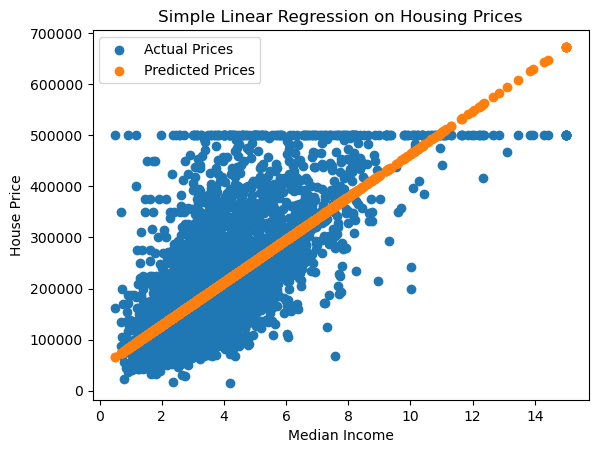

In [14]:
plt.scatter(X_test, y_test, label="Actual Prices")
plt.scatter(X_test, y_pred, label="Predicted Prices")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression on Housing Prices")
plt.legend()
plt.show()


In [15]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)


Coefficient: 79851.95644260355
Intercept: 207194.6937378876


In [16]:
def predict_house_price():
    try:
        income = float(input("Enter Median Income: "))
        
        # Convert to DataFrame
        input_data = pd.DataFrame([[income]], columns=['median_income'])
        
        # Scale input
        input_scaled = scaler.transform(input_data)
        
        # Predict
        prediction = model.predict(input_scaled)
        
        print("\n🏠 Predicted House Price: ₹", round(prediction[0], 2))
        
    except Exception as e:
        print("Error:", e)

# Run prediction
predict_house_price()


Enter Median Income:  10



🏠 Predicted House Price: ₹ 463798.22


In [17]:
pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
import ipywidgets as widgets
from IPython.display import display

def predict_ui(median_income):
    input_data = pd.DataFrame([[median_income]], columns=['median_income'])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    
    print("🏠 Predicted House Price:", round(prediction[0], 2))

slider = widgets.FloatSlider(
    value=3.0,
    min=0.5,
    max=15.0,
    step=0.1,
    description='Income:',
    continuous_update=False
)

widgets.interact(predict_ui, median_income=slider)


interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='Income:', max=15.0, min=0.5…

<function __main__.predict_ui(median_income)>